In [91]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
path="/content/car data.csv"
df = pd.read_csv(path)
# df.duplicated().sum()
# df.columns
# df.info()
df.drop_duplicates(inplace=True)
cat_col = df.select_dtypes('object').columns
for i in cat_col:
    print(df[i].value_counts())

Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              10
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 97, dtype: int64
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


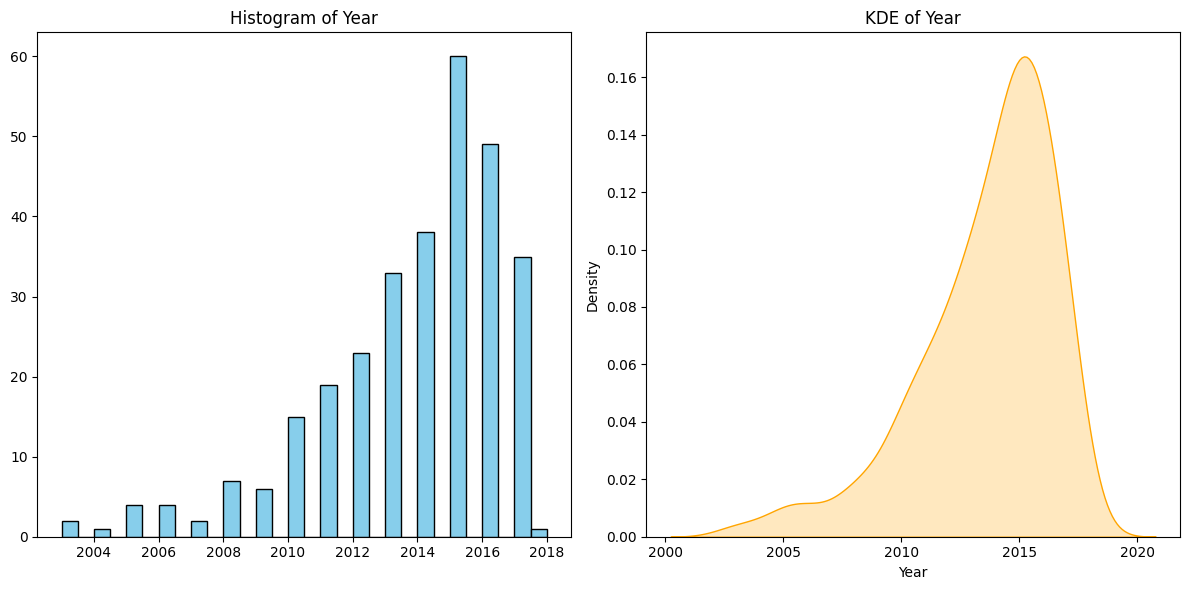

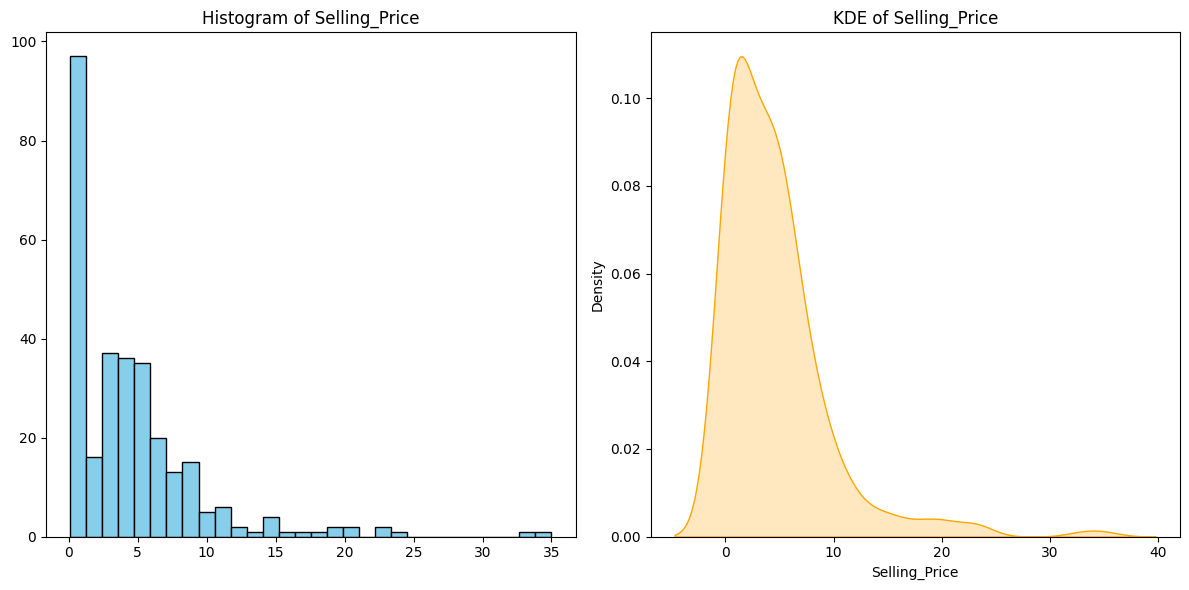

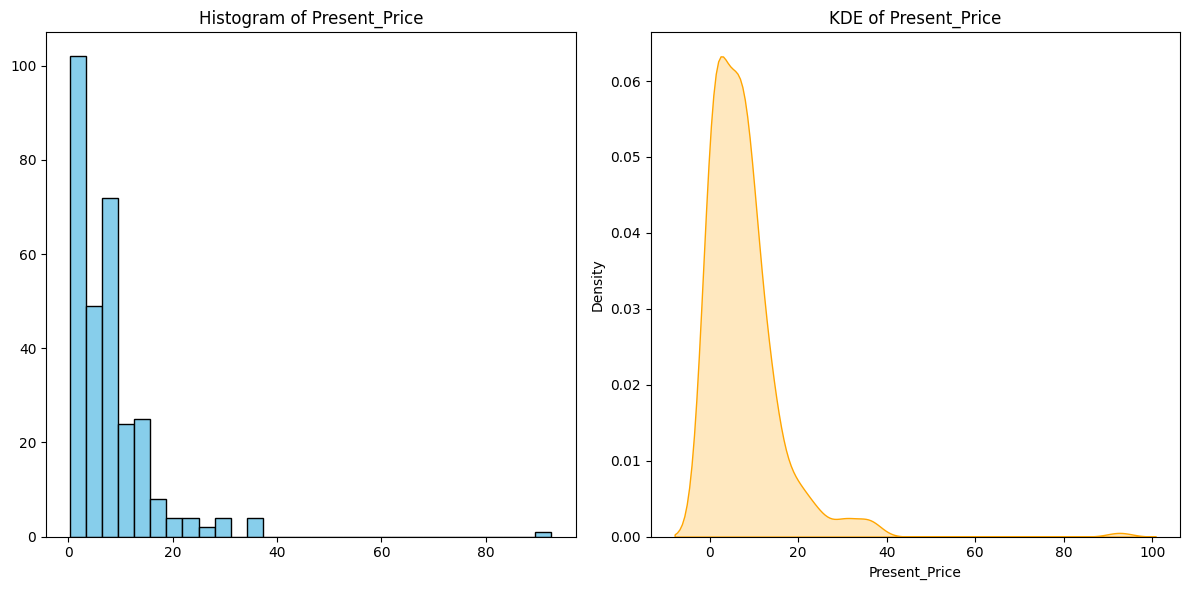

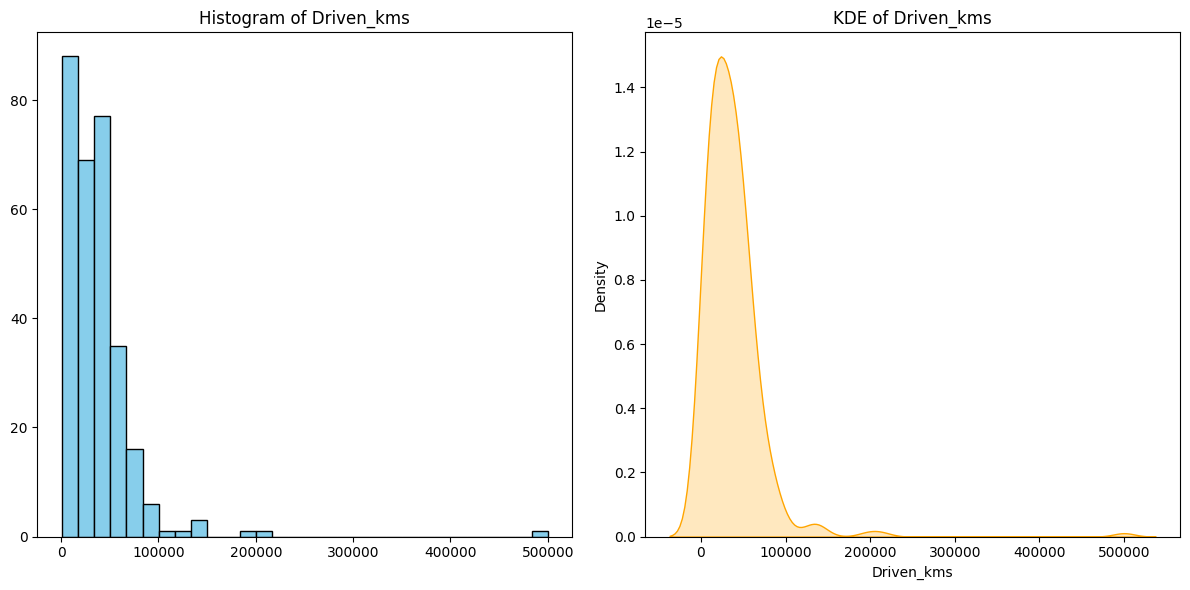

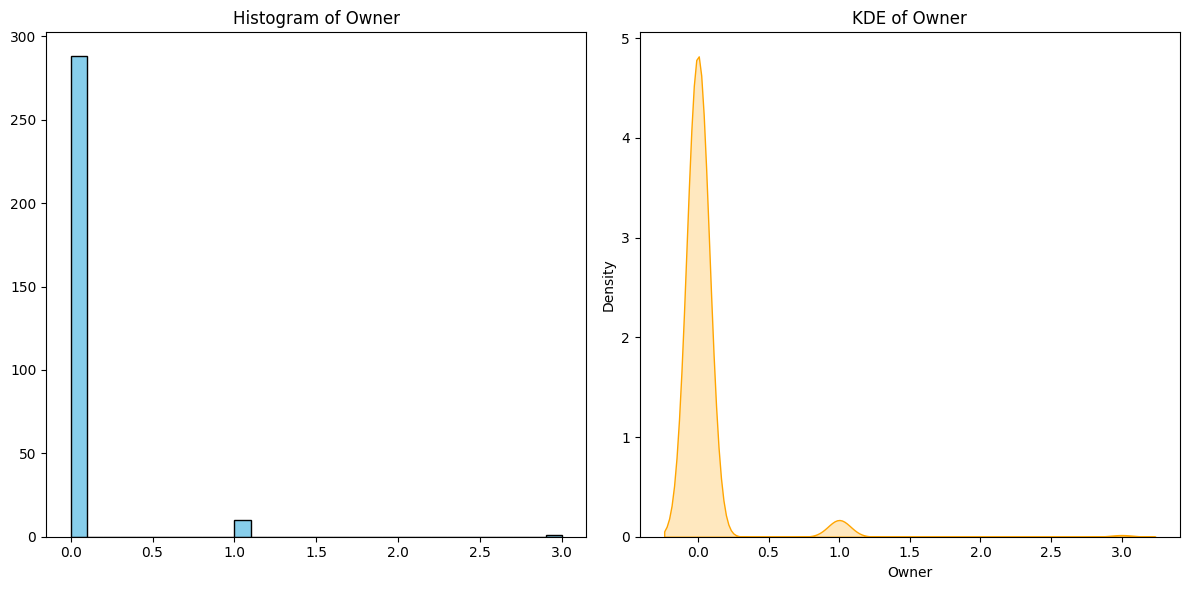

In [92]:
num_col = df.select_dtypes(['int64' , 'float64']).columns
for i in num_col:
    plt.figure(figsize=(12,6))
    plt.subplot(1, 2, 1)
    plt.hist(df[i], bins=30, color='skyblue' , edgecolor='black')
    plt.title(f'Histogram of {i}')

    plt.subplot(1, 2, 2)
    sns.kdeplot(df[i], color='orange' , fill=True)
    plt.title(f'KDE of {i}')

    plt.tight_layout()
    plt.show()

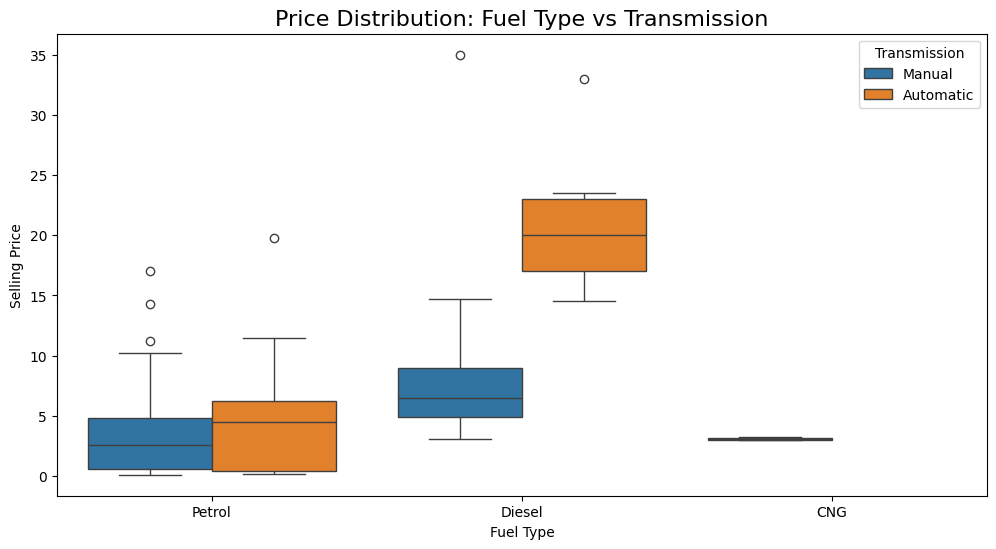

In [93]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Fuel_Type', y='Selling_Price', hue='Transmission', data=df)
plt.title('Price Distribution: Fuel Type vs Transmission', fontsize=16)
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.legend(title='Transmission')
plt.show()

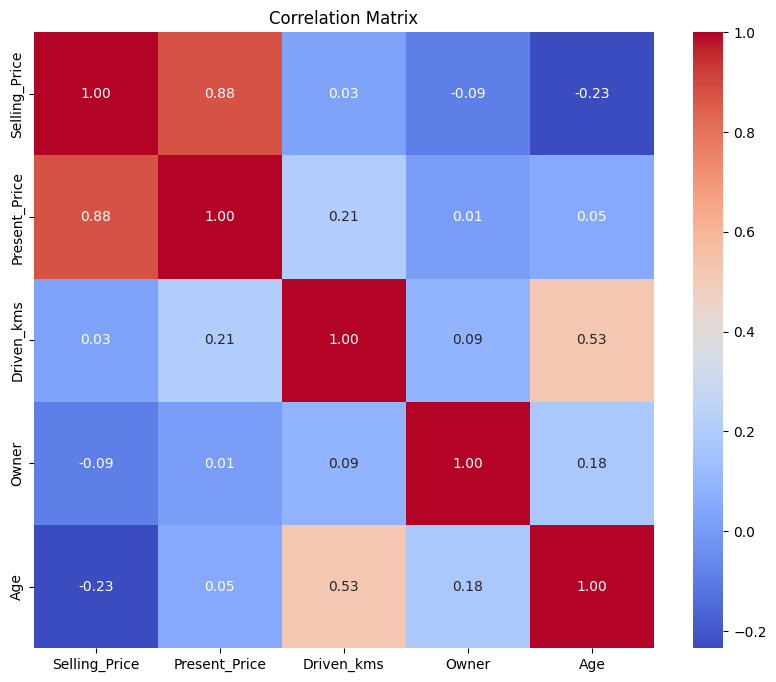

In [94]:
now = datetime.now().year
df['Age'] = now - df['Year']
df.drop(columns=['Year'] , inplace=True)
num_col = df.select_dtypes(['int64' , 'float64']).columns
corr = df[num_col].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [95]:
df['Brand'] = df['Car_Name'].str.split(' ').str[0]

# Now we can safely drop the original Car_Name column
df.drop(columns=['Car_Name'], inplace=True, errors='ignore')

# Re-identify categorical columns including the new 'Brand' column
cat_col = df.select_dtypes('object').columns

# Use pd.get_dummies for encoding
df = pd.get_dummies(df, columns=cat_col, drop_first=True)

# Display the prepared dataframe with Brand features
display(df.head())

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data encoded successfully! New shape: {df.shape}")

,Selling_Price,Present_Price,Driven_kms,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Brand_Bajaj,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,3.35,5.59,27000,0,12,False,True,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,13,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,7.25,9.85,6900,0,9,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,15,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,4.60,6.87,42450,0,12,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


Data encoded successfully! New shape: (299, 51)


In [96]:
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [97]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'SVM Regression': SVR(),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = []

# Train and evaluate with Cross-Validation
for name, model in models.items():
    X_curr = X_train_scaled if name in ['Linear Regression', 'SVM Regression'] else X_train

    # Cross-validation scores
    cv_r2 = cross_val_score(model, X_curr, y_train, cv=kf, scoring='r2').mean()
    cv_mse = -cross_val_score(model, X_curr, y_train, cv=kf, scoring='neg_mean_squared_error').mean()

    results.append({'Model': name, 'Avg CV R2': cv_r2, 'Avg CV MSE': cv_mse})

# Display Results
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Avg CV R2', ascending=False))

,Model,Avg CV R2,Avg CV MSE
0,Linear Regression,0.820981,6.061786
2,Decision Tree,0.660747,5.647080
1,SVM Regression,0.607100,11.851179


In [98]:
df_no_brand = pd.read_csv(path)
df_no_brand.drop_duplicates(inplace=True)
df_no_brand.drop(columns=['Car_Name'], inplace=True, errors='ignore')

now = datetime.now().year
df_no_brand['Age'] = now - df_no_brand['Year']
df_no_brand.drop(columns=['Year'], inplace=True)

cat_cols = df_no_brand.select_dtypes('object').columns
df_no_brand = pd.get_dummies(df_no_brand, columns=cat_cols, drop_first=True)

X_nb = df_no_brand.drop('Selling_Price', axis=1)
y_nb = df_no_brand['Selling_Price']

scaler_nb = StandardScaler()
X_nb_scaled = scaler_nb.fit_transform(X_nb)

models_nb = {
    'LR (No Brand)': LinearRegression(),
    'SVR (No Brand)': SVR(),
    'DT (No Brand)': DecisionTreeRegressor(random_state=42)
}

results_nb = []
for name, model in models_nb.items():
    X_curr = X_nb_scaled if 'DT' not in name else X_nb
    cv_r2 = cross_val_score(model, X_curr, y_nb, cv=kf, scoring='r2').mean()
    cv_mse = -cross_val_score(model, X_curr, y_nb, cv=kf, scoring='neg_mean_squared_error').mean()

    results_nb.append({'Model': name, 'Avg CV R2': cv_r2, 'Avg CV MSE': cv_mse})

print("Performance WITHOUT Brand Information (10-Fold CV)")
display(pd.DataFrame(results_nb).sort_values(by='Avg CV R2', ascending=False))

Performance WITHOUT Brand Information (10-Fold CV)


,Model,Avg CV R2,Avg CV MSE
2,DT (No Brand),0.886820,2.990432
0,LR (No Brand),0.823908,3.801019
1,SVR (No Brand),0.717961,9.003765


In [107]:
X_full = df.drop(['Selling_Price'], axis=1)
y_full = df['Selling_Price']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Re-scale predictors for distance-based models
scaler_f = StandardScaler()
X_train_f_scaled = scaler_f.fit_transform(X_train_f)
X_test_f_scaled = scaler_f.transform(X_test_f)

models_f = {
    'LR (Full Variance)': LinearRegression(),
    'SVR (Full Variance)': SVR(),
    'DT (Full Variance)': DecisionTreeRegressor(random_state=42)
}

results_f = []
for name, model in models_f.items():
    X_curr = X_train_f_scaled if 'DT' not in name else X_train_f
    model.fit(X_curr, y_train_f)
    preds = model.predict(X_test_f_scaled if 'DT' not in name else X_test_f)

    results_f.append({
        'Model': name,
        'R2 Score': r2_score(y_test_f, preds),
        'MSE': mean_squared_error(y_test_f, preds)
    })

print("Test Set Performance (No Clipping):")
display(pd.DataFrame(results_f).sort_values(by='R2 Score', ascending=False))

Test Set Performance (No Clipping):


,Model,R2 Score,MSE
0,LR (Full Variance),0.682609,8.180200
2,DT (Full Variance),0.623416,9.705805
1,SVR (Full Variance),0.543642,11.761832


In [105]:
df_limited = pd.read_csv(path)
df_limited.drop_duplicates(inplace=True)

# Keep all original features to maintain variance for luxury/high-end cars
df_limited.drop(columns=['Car_Name'], inplace=True, errors='ignore')

now = datetime.now().year
df_limited['Age'] = now - df_limited['Year']
df_limited.drop(columns=['Year'], inplace=True)

# Use log transformation to handle skewness mathematically
df_limited['Selling_Price_Log'] = np.log1p(df_limited['Selling_Price'])

cat_cols = df_limited.select_dtypes('object').columns
df_limited = pd.get_dummies(df_limited, columns=cat_cols, drop_first=True)

X_lim = df_limited.drop(['Selling_Price', 'Selling_Price_Log'], axis=1)
y_lim_log = df_limited['Selling_Price_Log']
y_lim_actual = df_limited['Selling_Price']

scaler_lim = StandardScaler()
X_lim_scaled = scaler_lim.fit_transform(X_lim)

models_lim = {
    'LR (lim ft)': LinearRegression(),
    'SVR (lim ft)': SVR(),
    'DT (lim ft)': DecisionTreeRegressor(random_state=42)
}

results_lim = []
for name, model in models_lim.items():
    X_curr = X_lim_scaled if 'DT' not in name else X_lim
    cv_r2 = cross_val_score(model, X_curr, y_lim_log, cv=kf, scoring='r2').mean()
    cv_mse = -cross_val_score(model, X_curr, y_lim_log, cv=kf, scoring='neg_mean_squared_error').mean()
    results_lim.append({'Model': name, 'Avg CV R2 (Log)': cv_r2, 'Avg CV MSE (Log)': cv_mse})

print("Performance with NO Clipping (Log Target + Full Feature Variance):")
display(pd.DataFrame(results_lim).sort_values(by='Avg CV R2 (Log)', ascending=False))

Performance with NO Clipping (Log Target + Full Feature Variance):


,Model,Avg CV R2 (Log),Avg CV MSE (Log)
2,DT (lim ft),0.935749,0.037372
1,SVR (lim ft),0.917120,0.053539
0,LR (lim ft),0.875144,0.081891


lets do XGB R

In [108]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Re-train XGBoost on the uncapped features
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

# Fit on uncapped X_lim and log-transformed target
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           cv=kf, scoring='r2', n_jobs=-1, verbose=1)

grid_search.fit(X_lim, y_lim_log)

best_xgb = grid_search.best_estimator_
print(f"Best Parameters (No Clip): {grid_search.best_params_}")
print(f"Best CV R2 (Log Target, No Clip): {grid_search.best_score_:.4f}")

Fitting 10 folds for each of 54 candidates, totalling 540 fits
Best Parameters (No Clip): {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV R2 (Log Target, No Clip): 0.9704


In [110]:
# Update final comparison with the latest results (No Clip)
xgb_log_r2_cv = cross_val_score(best_xgb, X_lim, y_lim_log, cv=kf, scoring='r2').mean()
xgb_log_mse_cv = -cross_val_score(best_xgb, X_lim, y_lim_log, cv=kf, scoring='neg_mean_squared_error').mean()

xgb_row = pd.DataFrame([{
    'Model': 'XGBoost (lim ft)',
    'Avg CV R2 (Log)': xgb_log_r2_cv,
    'Avg CV MSE (Log)': xgb_log_mse_cv
}])

final_comparison = pd.concat([pd.DataFrame(results_lim), xgb_row], ignore_index=True)

print("Final Model Comparison (No Feature Clipping):")
display(final_comparison.sort_values(by='Avg CV R2 (Log)', ascending=False))

Final Model Comparison (No Feature Clipping):


,Model,Avg CV R2 (Log),Avg CV MSE (Log)
3,XGBoost (lim ft),0.970445,0.018112
2,DT (lim ft),0.935749,0.037372
1,SVR (lim ft),0.917120,0.053539
0,LR (lim ft),0.875144,0.081891


### Visualizing Model Predictions vs. Driven Kilometers
We compare the actual selling prices against predictions from our top two models (XGBoost and SVR) to see how they handle the mileage-to-price relationship.

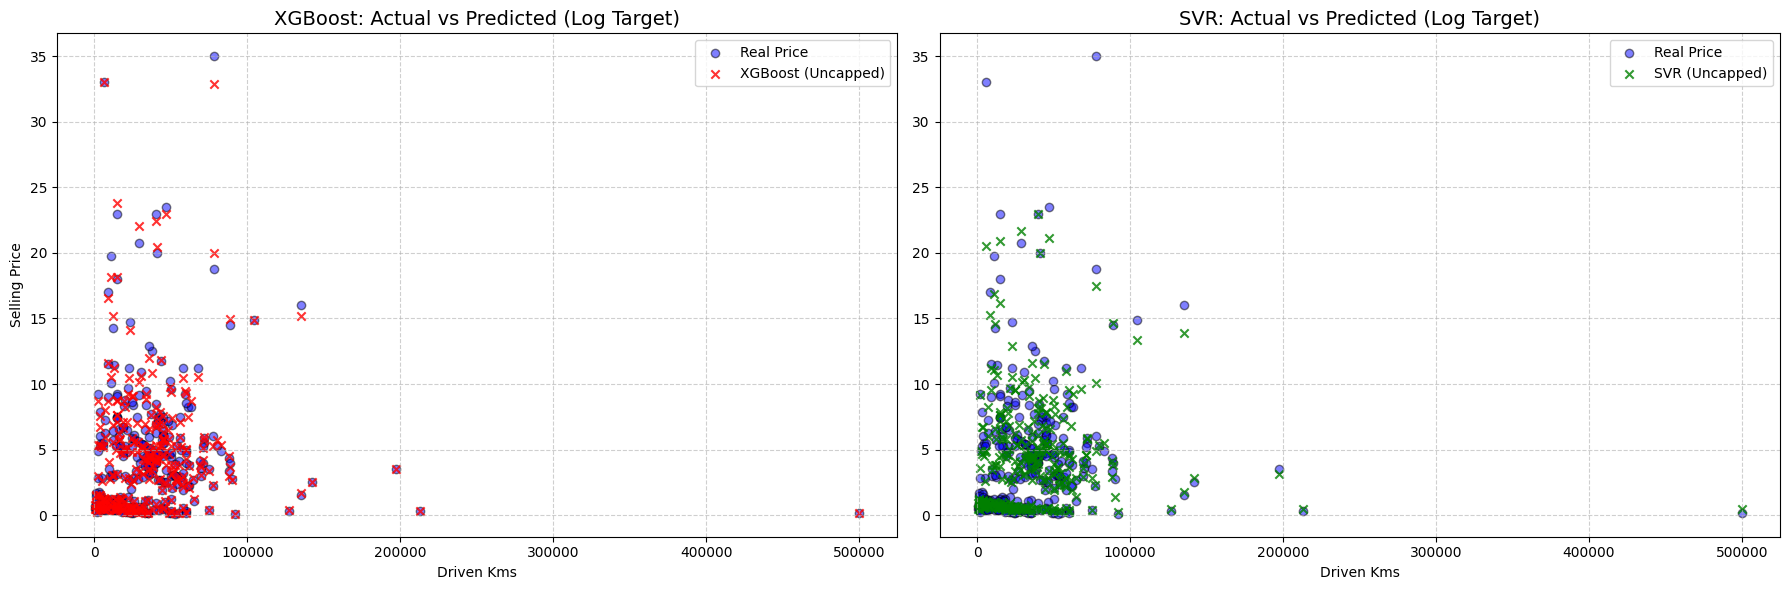

In [111]:
import matplotlib.pyplot as plt

# Get log predictions and convert back to actual prices using expm1
best_xgb.fit(X_lim, y_lim_log)
y_pred_log_xgb = best_xgb.predict(X_lim)
y_pred_xgb_actual = np.expm1(y_pred_log_xgb)

# Fit and predict with SVR from the updated dictionary
svr_model = models_lim['SVR (lim ft)']
svr_model.fit(X_lim_scaled, y_lim_log)
y_pred_log_svr = svr_model.predict(X_lim_scaled)
y_pred_svr_actual = np.expm1(y_pred_log_svr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Plot 1: XGBoost (Actual Scale)
ax1.scatter(df_limited['Driven_kms'], y_lim_actual, color='blue', alpha=0.5, label='Real Price', edgecolors='k')
ax1.scatter(df_limited['Driven_kms'], y_pred_xgb_actual, color='red', marker='x', alpha=0.8, label='XGBoost (Uncapped)')
ax1.set_title('XGBoost: Actual vs Predicted (Log Target)', fontsize=14)
ax1.set_xlabel('Driven Kms')
ax1.set_ylabel('Selling Price')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: SVR (Actual Scale)
ax2.scatter(df_limited['Driven_kms'], y_lim_actual, color='blue', alpha=0.5, label='Real Price', edgecolors='k')
ax2.scatter(df_limited['Driven_kms'], y_pred_svr_actual, color='green', marker='x', alpha=0.8, label='SVR (Uncapped)')
ax2.set_title('SVR: Actual vs Predicted (Log Target)', fontsize=14)
ax2.set_xlabel('Driven Kms')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()